In [69]:
import numpy 
import pandas
import matplotlib.pyplot as plt
import matplotlib
import scipy
import glob
import seaborn
from scipy.optimize import curve_fit
import itertools

pandas.set_option('display.max_columns', None)

### Import

In [70]:
def ExtractGenAndRecoFeatures(
    PATH,
    GENERATED_NAME,
    GENERATED_VARS,
    RECONSTRUCTED_NAME,
    RECONSTRUCTED_VARS
):

    print("Extracting generated variables...")
    Gen = pandas.read_csv(
        PATH + GENERATED_NAME,
        delimiter = "\t", 
        names = GENERATED_VARS, 
        index_col = False
    )
    print("Extracting reconstructed variables...")
    Reco = pandas.read_csv(
        PATH + RECONSTRUCTED_NAME,
        delimiter = "\t", 
        names = RECONSTRUCTED_VARS, 
        index_col = False
    )
    
    return Gen, Reco

In [71]:
PATH = "/exp/icarus/app/users/msotgia/analysis/twoDRecoStudies/showerValidations/V10Validation/202605/" # "/exp/icarus/app/users/rtriozzi/sbnana/V10Validation/output/reco/"
GENERATED_VARS = [
    "source", "run", "event",
    "vtxxtruth", "vtxytruth", "vtxztruth",
    "nuenergy", "collenergytruth", "ind2energytruth", "ind1energytruth",
    "dirxtruth", "dirytruth", "dirztruth", 
    "nprotons", "iscc1e0pi"
]
RECONSTRUCTED_VARS = [
    "source", "run", "event",
    "vtxxtruth", "vtxytruth", "vtxztruth", "vtxx", "vtxy", "vtxz", "vtx_vstruth",
    "tmatcheff", "nuenergy", "startendenergy", "trueenergyinhits", "shwpdg", "nprotons", "iscc1e0pi",
    "dirx", "diry", "dirz", "dirxtruth", "dirytruth", "dirztruth", "dirxztruth", "diryztruth",
    "collenergy", "ind2energy", "ind1energy", "collenergytruth", "ind2energytruth", "ind1energytruth", "collenergy_vstruth", "ind2energy_vstruth", "ind1energy_vstruth",
    "colldedx", "ind2dedx", "ind1dedx", "bestdedx",
    "hitcomp", "ecomp", "hitpur", "epur", "openangle", "convgap"
]

# Testing 

In [72]:
### 2D + DNN-ROI, with pulse trains
GENERATED_NAME = "TESTING_1uNp_flats_Generated.txt"
RECONSTRUCTED_NAME = "TESTING_1uNp_flats_Reconstructed.txt"
Gen_1uNp, Reco_1uNp = ExtractGenAndRecoFeatures(PATH, GENERATED_NAME, GENERATED_VARS, RECONSTRUCTED_NAME, RECONSTRUCTED_VARS)

### 2D + DNN-ROI, without pulse trains
GENERATED_NAME = "TESTING_1eNp_flats_Generated.txt"
RECONSTRUCTED_NAME = "TESTING_1eNp_flats_Reconstructed.txt"
Gen_1eNp, Reco_1eNp = ExtractGenAndRecoFeatures(PATH, GENERATED_NAME, GENERATED_VARS, RECONSTRUCTED_NAME, RECONSTRUCTED_VARS)

Extracting generated variables...
Extracting reconstructed variables...
Extracting generated variables...
Extracting reconstructed variables...


In [79]:
Reco = Reco_1uNp

Mask = (Reco.isFV == 1) & (Reco.hitcomp > 0.5) & (Reco.hitpur > 0.5) & (Reco.vtx_vstruth < 10) #& (Reco.ind1dedx <1.5) & (Reco.dirxtruth < -0.5) & (Reco.ind2dedx < 1.5) & (Reco.ind1dedx > 0) & (Reco.ind2dedx > 0)
Reco[Mask][['source', 'run', 'event', 'ind1dedx', 'ind2dedx', 'dirxtruth', 'hitcomp', 'hitpur']].to_csv(PATH + 'TESTING_1uNp_Flats_Reconstructed_Masked.csv')

In [80]:
Reco = Reco_1eNp

Mask = (Reco.isFV == 1) & (Reco.hitcomp > 0.5) & (Reco.hitpur > 0.5) & (Reco.vtx_vstruth < 10) #& (Reco.ind1dedx <1.5) & (Reco.dirxtruth < -0.5) & (Reco.ind2dedx < 1.5) & (Reco.ind1dedx > 0) & (Reco.ind2dedx > 0)
Reco[Mask][['source', 'run', 'event', 'ind1dedx', 'ind2dedx', 'dirxtruth', 'hitcomp', 'hitpur']].to_csv(PATH + 'TESTING_1eNp_Flats_Reconstructed_Masked.csv')

In [4]:
### 2D + DNN-ROI, with pulse trains
GENERATED_NAME = "2D_DNN_1uNpMpi0_noPulses_Generated.txt"
RECONSTRUCTED_NAME = "2D_DNN_1uNpMpi0_noPulses_Reconstructed.txt"
Gen_1uNp, Reco_1uNp = ExtractGenAndRecoFeatures(PATH, GENERATED_NAME, GENERATED_VARS, RECONSTRUCTED_NAME, RECONSTRUCTED_VARS)

### 2D + DNN-ROI, without pulse trains
GENERATED_NAME = "2D_DNN_1eNpMpi0_noPulses_Generated.txt"
RECONSTRUCTED_NAME = "2D_DNN_1eNpMpi0_noPulses_Reconstructed.txt"
Gen_1eNpMpi0, Reco_1eNpMpi0 = ExtractGenAndRecoFeatures(PATH, GENERATED_NAME, GENERATED_VARS, RECONSTRUCTED_NAME, RECONSTRUCTED_VARS)

### 2D + legacy ROIs, with pulse trains
GENERATED_NAME = "2D_DNN_1eNp0pi0_noPulses_Generated.txt"
RECONSTRUCTED_NAME = "2D_DNN_1eNp0pi0_noPulses_Reconstructed.txt"
Gen_1eNp0pi0, Reco_1eNp0pi0 = ExtractGenAndRecoFeatures(PATH, GENERATED_NAME, GENERATED_VARS, RECONSTRUCTED_NAME, RECONSTRUCTED_VARS)

## 1D
GENERATED_NAME = "2D_DNN_baseline_Generated.txt"
RECONSTRUCTED_NAME = "2D_DNN_baseline_Reconstructed.txt"
Gen_baseline, Reco_baseline = ExtractGenAndRecoFeatures(PATH, GENERATED_NAME, GENERATED_VARS, RECONSTRUCTED_NAME, RECONSTRUCTED_VARS)

Extracting generated variables...
Extracting reconstructed variables...


Extracting generated variables...
Extracting reconstructed variables...
Extracting generated variables...
Extracting reconstructed variables...
Extracting generated variables...
Extracting reconstructed variables...


In [74]:
### FV cut
def IsInFV(x, y, z):
    return int((((x < -61.94-25) & (x > -358.49+25)) | ((x > 61.94+25) & (x < 358.49-25))) & (((y > -181.86+25) & (y < 134.96-25)) & ((z > -894.95+30) & (z < 894.95-50))))

In [75]:
for df in [Gen_1uNp, Reco_1uNp, Gen_1eNp, Reco_1eNp]:
    df['isFV'] = df.apply(
        lambda row: IsInFV(row.vtxxtruth, row.vtxytruth, row.vtxztruth),
        axis = 1
    )

In [6]:
for df in [Gen_1uNp, Reco_1uNp, Gen_1eNpMpi0, Reco_1eNpMpi0, Gen_1eNp0pi0, Reco_1eNp0pi0, Gen_baseline, Reco_baseline]:
    df['isFV'] = df.apply(
        lambda row: IsInFV(row.vtxxtruth, row.vtxytruth, row.vtxztruth),
        axis = 1
    )

## Reconstruction efficiency

For each signal processing or reconstruction change, extract generated and reconstructed features of the true electron and of the largest shower (in terms of hits in Collection) associated with it. In this way, the "reconstruction efficiency" can be tested with any requirement: e.g., asking that the reconstructed shower has decent (>50%) completeness and purity, or with any stronger requirement (e.g., vertex tightly right, energy decently captured, dE/dx in agreement with expectation).


For each generated neutrino, the reconstruction may split the neutrino into multiple slices. Multiple slices for a given event will be truth-matched to the signal, but they should count as **one** single neutrino in the efficiency estimation. For properties, just consider the slice with the highest slice-level truth-match efficiency.

In [7]:
def ReconstructionEfficiency(
    Gen,
    Reco,
    Var,
    Binning
):

    # Deal with slice splitting:
    # for a unique trouple (source, run, event)
    # choose the one with higher t-match efficiency
    HiEffSliceIdx = Reco.groupby(['source', 'run', 'event', 'vtxxtruth'])['tmatcheff'].idxmax()
    Reco_Eff = Reco.loc[HiEffSliceIdx].reset_index(drop=True)

    # Signal definition
    TruthSelection = (Gen.isFV == 1)
    Gen_Eff = Gen[TruthSelection]
    
    # Selection
    TruthSelection = (Reco_Eff.isFV == 1)
    Selection = TruthSelection & (Reco_Eff.hitcomp > 0.5) & (Reco_Eff.hitpur > 0.5) & (Reco_Eff.vtx_vstruth < 10) # & (Reco_Eff.convgap < 10) & (Reco_Eff.openangle > 0.1) & (Reco_Eff.openangle < 10)
    # Selection = TruthSelection & (Reco_Eff.colldedx > 0.)

    # Total efficiency
    TotalEfficiency = len(Reco_Eff[Selection]) / len(Gen_Eff)
    
    # Generated 
    yGen, bins = numpy.histogram(
        Gen_Eff[Var], 
        bins = binning
    )
    x = (bins[:-1] + bins[1:]) / 2.

    # Selected
    y, bins = numpy.histogram(
        Reco_Eff[Selection][Var], 
        bins=binning
    )
    BinnedEfficiency = y / yGen
    BinomErrors = [[k/n - scipy.stats.binomtest(k, n).proportion_ci(confidence_level=0.68).low, scipy.stats.binomtest(k, n).proportion_ci(confidence_level=0.68).high - k/n] for k, n in zip(y, yGen)]
    
    return x, BinnedEfficiency, BinomErrors, TotalEfficiency

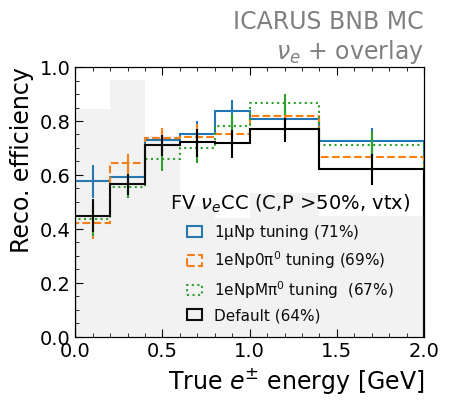

In [37]:
fig, ax = plt.subplots(figsize=(4.5, 3.5))

# Variable

'''
Var = "nuenergy"
# width = 0.2; binning = numpy.arange(0., 4+width, width)
binning = [0, 0.4, 0.8, 1.2, 1.6, 2, 2.4, 2.8, 4]
VarName = "True $\\nu_e$ energy [GeV]"
'''


Var = "collenergytruth"
binning = [0, 0.2, 0.4, 0.6, 0.8, 1, 1.4, 2]
VarName = "True $e^{\pm}$ energy [GeV]"


'''
Var = "dirytruth"
binning = [-1, -0.8, -0.6, -0.4, -0.2, 0, 0.2, 0.4, 0.6, 0.8, 1]
VarName = "cos($\\theta_y^{\\mathrm{true}}$)"
'''

'''
Var = "dirztruth"
binning = [-1, 0, 0.5, 0.7, 0.8, 0.9, 1]
VarName = "cos($\\theta_z^{\\mathrm{true}}$)"
'''

### 2D + DNN-ROI, with pulse trains
x, eff, err, totEff = ReconstructionEfficiency(Gen_1uNp, Reco_1uNp, Var, binning)
ax.hist(x, weights=eff, bins=binning, histtype='step', lw=1.5, ec=f'C0', label=f'$\\mathrm{{1\\mu N p}}$ tuning ({100*totEff:.0f}%)')
ax.errorbar(x, eff, yerr=numpy.array(err).T, lw=1.5, c=f'C0', marker='', ls='')

### 2D + DNN-ROI, without pulse trains
x, eff, err, totEff = ReconstructionEfficiency(Gen_1eNp0pi0, Reco_1eNp0pi0, Var, binning)
ax.hist(x, weights=eff, bins=binning, histtype='step', lw=1.5,ls='--', ec=f'C1', label=f'$\\mathrm{{1e N p 0 \\pi^0}}$ tuning ({100*totEff:.0f}%)')
ax.errorbar(x, eff, yerr=numpy.array(err).T, lw=1.5, c=f'C1', marker='', ls='')

### 2D + legacy ROIs, with pulse trains
x, eff, err, totEff = ReconstructionEfficiency(Gen_1eNpMpi0, Reco_1eNpMpi0, Var, binning)
ax.hist(x, weights=eff, bins=binning, histtype='step', lw=1.5,ls=':', ec=f'C2', label=f'$\\mathrm{{1e N p M \\pi^0}}$ tuning  ({100*totEff:.0f}%)')
ax.errorbar(x, eff, yerr=numpy.array(err).T, lw=1.5, c=f'C2', marker='', ls='')

### 1D
x, eff, err, totEff = ReconstructionEfficiency(Gen_baseline, Reco_baseline, Var, binning)
ax.hist(x, weights=eff, bins=binning, histtype='step', lw=1.5,ls='-', ec=f'black', label=f'Default ({100*totEff:.0f}%)')
ax.errorbar(x, eff, yerr=numpy.array(err).T, lw=1.5, c=f'black', marker='', ls='')

# labels
ax.set_title("ICARUS BNB MC\n$\\nu_e$ + overlay", fontsize=17, loc='right', color='gray')
ax.set_xlabel(VarName, fontsize=17, loc='right')
ax.set_ylabel("Reco. efficiency", fontsize=17, loc='top')
leg = ax.legend(frameon=False, fancybox=False, fontsize=11, loc='lower right', handlelength=1, ncol=1, title='FV $\\nu_e$CC (C,P >50%, vtx)')
leg.get_title().set_fontsize('14')

# ticks
ax.tick_params(labelsize=14, length=6, direction='in', right=True, top=True)
ax.tick_params(which='minor', length=3, direction='in', right=True, top=True)
ax.minorticks_on()

# generated distribution
ax2 = ax.twinx()
ax2.hist(Gen_baseline[Var], bins=binning, zorder=-3, fc='gray', alpha=0.1, label='')
ax2.set_yticks([])

# gfx
ax.set_xlim(binning[0], binning[-1])
ax.set_ylim(0., 1.) # ax.set_ylim(0.4, 0.9)
#ax.axhline(1, ls='-', c='black', lw=1)
fig.savefig(f"/exp/icarus/app/users/msotgia/analysis/twoDRecoStudies/showerValidations/V10Validation/202605/plots/NueCC_RecoEfficiency_{Var}.png", bbox_inches='tight', dpi=300)
plt.show()

Here I was making plots with the dE/dx reconstruction efficiency in mind.

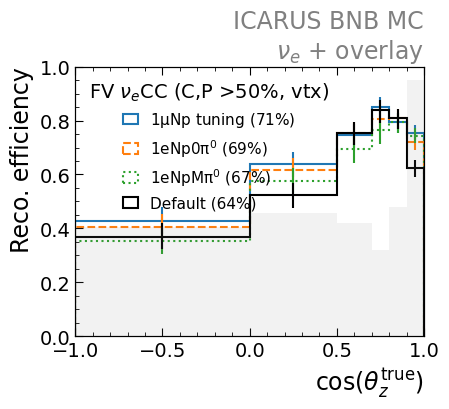

In [38]:
fig, ax = plt.subplots(figsize=(4.5, 3.5))

# Variable


'''
Var = "dirytruth"
binning = [-1, -0.8, -0.6, -0.4, -0.2, 0, 0.2, 0.4, 0.6, 0.8, 1]
VarName = "cos($\\theta_y^{\\mathrm{true}}$)"
'''


Var = "dirztruth"
binning = [-1, 0, 0.5, 0.7, 0.8, 0.9, 1]
VarName = "cos($\\theta_z^{\\mathrm{true}}$)"


### 2D + DNN-ROI, with pulse trains
x, eff, err, totEff = ReconstructionEfficiency(Gen_1uNp, Reco_1uNp, Var, binning)
ax.hist(x, weights=eff, bins=binning, histtype='step', lw=1.5, ec=f'C0', label=f'$\\mathrm{{1\\mu N p}}$ tuning ({100*totEff:.0f}%)')
ax.errorbar(x, eff, yerr=numpy.array(err).T, lw=1.5, c=f'C0', marker='', ls='')

### 2D + DNN-ROI, without pulse trains
x, eff, err, totEff = ReconstructionEfficiency(Gen_1eNp0pi0, Reco_1eNp0pi0, Var, binning)
ax.hist(x, weights=eff, bins=binning, histtype='step', lw=1.5,ls='--', ec=f'C1', label=f'$\\mathrm{{1e N p 0 \\pi^0}}$ ({100*totEff:.0f}%)')
ax.errorbar(x, eff, yerr=numpy.array(err).T, lw=1.5, c=f'C1', marker='', ls='')

### 2D + legacy ROIs, with pulse trains
x, eff, err, totEff = ReconstructionEfficiency(Gen_1eNpMpi0, Reco_1eNpMpi0, Var, binning)
ax.hist(x, weights=eff, bins=binning, histtype='step', lw=1.5,ls=':', ec=f'C2', label=f'$\\mathrm{{1e N p M \\pi^0}}$ ({100*totEff:.0f}%)')
ax.errorbar(x, eff, yerr=numpy.array(err).T, lw=1.5, c=f'C2', marker='', ls='')

### 1D
x, eff, err, totEff = ReconstructionEfficiency(Gen_baseline, Reco_baseline, Var, binning)
ax.hist(x, weights=eff, bins=binning, histtype='step', lw=1.5,ls='-', ec=f'black', label=f'Default ({100*totEff:.0f}%)')
ax.errorbar(x, eff, yerr=numpy.array(err).T, lw=1.5, c=f'black', marker='', ls='')

# labels
ax.set_title("ICARUS BNB MC\n$\\nu_e$ + overlay", fontsize=17, loc='right', color='gray')
ax.set_xlabel(VarName, fontsize=17, loc='right')
ax.set_ylabel("Reco. efficiency", fontsize=17, loc='top')
leg = ax.legend(frameon=False, fancybox=False, fontsize=11, loc='upper left', handlelength=1, ncol=1, title='FV $\\nu_e$CC (C,P >50%, vtx)')
leg.get_title().set_fontsize('14')

# ticks
ax.tick_params(labelsize=14, length=6, direction='in', right=True, top=True)
ax.tick_params(which='minor', length=3, direction='in', right=True, top=True)
ax.minorticks_on()

# generated distribution
ax2 = ax.twinx()
ax2.hist(Gen_baseline[Var], bins=binning, zorder=-3, fc='gray', alpha=0.1, label='')
ax2.set_yticks([])

# gfx
ax.set_xlim(binning[0], binning[-1])
ax.set_ylim(0., 1) # ax.set_ylim(0.4, 0.9)
#ax.axhline(1, ls='-', c='black', lw=1)
fig.savefig(f"/exp/icarus/app/users/msotgia/analysis/twoDRecoStudies/showerValidations/V10Validation/202605/plots/NueCC_RecoEfficiency_dEdx_{Var}.png", bbox_inches='tight', dpi=300)
plt.show()

## Shower variables

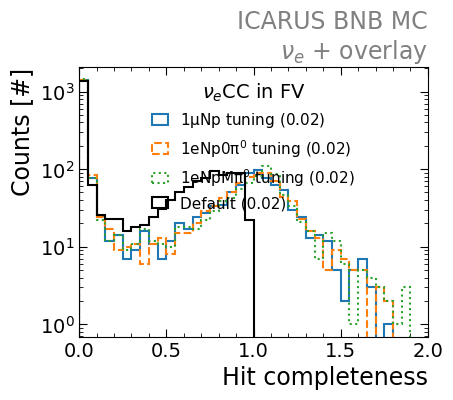

In [39]:
fig, ax = plt.subplots(figsize=(4.5, 3.5))

# Variable

# Var = "openangle"
# width = 1; binning = numpy.arange(0, 25+width, width)
# VarName = "Opening angle [deg.]"

# Var = "convgap"
# width = 1.; binning = numpy.arange(0, 15+width, width)
# VarName = "Conversion gap [cm]"

Var = "hitcomp"
width = 0.05; binning = numpy.arange(0, 2+width, width)
VarName = "Hit completeness"

# Var = "hitpur"
# width = 0.05; binning = numpy.arange(0, 1+width, width)
# VarName = "Hit purity"

### 2D + DNN-ROI, with pulse trains
Mask = (Reco_1uNp.isFV == 1) & (Reco_1uNp.hitcomp > 0 ) & (Reco_1uNp.hitpur > 0) #& (Reco_1uNp.hitcomp > 0.5) & (Reco_1uNp.hitpur > 0.5) & (Reco_1uNp.vtx_vstruth < 10)
ax.hist(numpy.clip(Reco_1uNp[Mask][Var], binning[0], binning[-1]), bins=binning, histtype='step', lw=1.5, ec=f'C0', label=f'$\\mathrm{{1\\mu N p}}$ tuning ({numpy.median(Reco_1uNp[Mask][Var]):.2f})', density=False)

### 2D + DNN-ROI, without pulse trains
Mask = (Reco_1eNp0pi0.isFV == 1) & (Reco_1eNp0pi0.hitcomp > 0 ) & (Reco_1eNp0pi0.hitpur > 0) #& (Reco_1eNp0pi0.hitcomp > 0.5) & (Reco_1eNp0pi0.hitpur > 0.5) & (Reco_1eNp0pi0.vtx_vstruth < 10)
ax.hist(numpy.clip(Reco_1eNp0pi0[Mask][Var], binning[0], binning[-1]), bins=binning, histtype='step', lw=1.5,ls='--', ec=f'C1', label=f'$\\mathrm{{1e N p 0 \\pi^0}}$ tuning ({numpy.median(Reco_1eNp0pi0[Mask][Var]):.2f})', density=False)

### 2D + legacy ROIs, with pulse trains
Mask = (Reco_1eNpMpi0.isFV == 1) & (Reco_1eNpMpi0.hitcomp > 0 ) & (Reco_1eNpMpi0.hitpur > 0) #& (Reco_1eNpMpi0.hitcomp > 0.5) & (Reco_1eNpMpi0.hitpur > 0.5) & (Reco_1eNpMpi0.vtx_vstruth < 10)
ax.hist(numpy.clip(Reco_1eNpMpi0[Mask][Var], binning[0], binning[-1]), bins=binning, histtype='step', lw=1.5,ls=':', ec=f'C2', label=f'$\\mathrm{{1e N p M \\pi^0}}$ tuning ({numpy.median(Reco_1eNpMpi0[Mask][Var]):.2f})', density=False)

### 1D
Mask = (Reco_baseline.isFV == 1) & (Reco_baseline.hitcomp > 0 ) & (Reco_baseline.hitpur > 0) #& (Reco_baseline.hitcomp > 0.5) & (Reco_baseline.hitpur > 0.5) & (Reco_baseline.vtx_vstruth < 10)
ax.hist(numpy.clip(Reco_baseline[Mask][Var], binning[0], binning[-1]), bins=binning, histtype='step', lw=1.5,ls='-', ec=f'black', label=f'Default ({numpy.median(Reco_baseline[Mask][Var]):.2f})', density=False)

# labels
ax.set_title("ICARUS BNB MC\n$\\nu_e$ + overlay", fontsize=17, loc='right', color='gray')
ax.set_xlabel(VarName, fontsize=17, loc='right')
ax.set_ylabel("Counts [#]", fontsize=17, loc='top')
leg = ax.legend(frameon=False, fontsize=11, loc='upper center', handlelength=1, ncol=1, title='$\\nu_e$CC in FV')
leg.get_title().set_fontsize('14')

# ticks
ax.tick_params(labelsize=14, length=6, direction='in', right=True, top=True)
ax.tick_params(which='minor', length=3, direction='in', right=True, top=True)
ax.minorticks_on()
# ax.set_yscale('log')

# gfx
ax.set_xlim(binning[0], binning[-1])
ax.set_yscale('log')

fig.savefig(f"/exp/icarus/app/users/msotgia/analysis/twoDRecoStudies/showerValidations/V10Validation/202605/plots/NueCC_ShowerReco_{Var}.png", bbox_inches='tight', dpi=300)
plt.show()

## Energy reconstruction

TODO. Write function to extract given binning the CB distributions and fits, showing them for debugging purposes.

Remember to also check bias (can be calibrated though) of energy reconstruction, and also dE/dx (e.g., insight in Ind1).

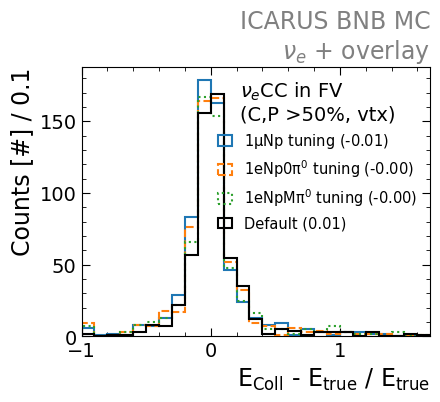

In [43]:
fig, ax = plt.subplots(figsize=(4.5, 3.5))

# Variable

'''
Var = "ind1energy_vstruth"
width = 0.1; binning = numpy.arange(-1, 1.7+width, width)
VarName = "E$_{\mathrm{Ind1}}$ - E$_{\mathrm{true}}$ / E$_{\mathrm{true}}$"
'''

'''
Var = "ind2energy_vstruth"
width = 0.1; binning = numpy.arange(-1, 1.7+width, width)
VarName = "E$_{\mathrm{Ind2}}$ - E$_{\mathrm{true}}$ / E$_{\mathrm{true}}$"
'''

# '''
Var = "collenergy_vstruth"
width = 0.1; binning = numpy.arange(-1, 1.7+width, width)
VarName = "E$_{\mathrm{Coll}}$ - E$_{\mathrm{true}}$ / E$_{\mathrm{true}}$"
# '''

## 2D + DNN-ROI, with pulse trains
Mask = (Reco_1uNp.isFV == 1) & (Reco_1uNp.hitcomp > 0.5) & (Reco_1uNp.hitpur > 0.5) & (Reco_1uNp.vtx_vstruth < 10)
ax.hist(numpy.clip(Reco_1uNp[Mask][Var], binning[0], binning[-1]), bins=binning, histtype='step', lw=1.5, ec=f'C0', label=f'$\\mathrm{{1\\mu N p}}$ tuning ({numpy.median(Reco_1uNp[Mask][Var]):.2f})', density=False)

### 2D + DNN-ROI, without pulse trains
Mask = (Reco_1eNp0pi0.isFV == 1) & (Reco_1eNp0pi0.hitcomp > 0.5) & (Reco_1eNp0pi0.hitpur > 0.5) & (Reco_1eNp0pi0.vtx_vstruth < 10)
ax.hist(numpy.clip(Reco_1eNp0pi0[Mask][Var], binning[0], binning[-1]), bins=binning, histtype='step', lw=1.5,ls='--', ec=f'C1', label=f'$\\mathrm{{1e N p 0 \\pi^0}}$ tuning ({numpy.median(Reco_1eNp0pi0[Mask][Var]):.2f})', density=False)

### 2D + legacy ROIs, with pulse trains
Mask = (Reco_1eNpMpi0.isFV == 1) & (Reco_1eNpMpi0.hitcomp > 0.5) & (Reco_1eNpMpi0.hitpur > 0.5) & (Reco_1eNpMpi0.vtx_vstruth < 10)
ax.hist(numpy.clip(Reco_1eNpMpi0[Mask][Var], binning[0], binning[-1]), bins=binning, histtype='step', lw=1.5,ls=':', ec=f'C2', label=f'$\\mathrm{{1e N p M \\pi^0}}$ tuning ({numpy.median(Reco_1eNpMpi0[Mask][Var]):.2f})', density=False)

### 1D
Mask = (Reco_baseline.isFV == 1) & (Reco_baseline.hitcomp > 0.5) & (Reco_baseline.hitpur > 0.5) & (Reco_baseline.vtx_vstruth < 10)
ax.hist(numpy.clip(Reco_baseline[Mask][Var], binning[0], binning[-1]), bins=binning, histtype='step', lw=1.5,ls='-', ec=f'black', label=f'Default ({numpy.median(Reco_baseline[Mask][Var]):.2f})', density=False)

# labels
ax.set_title("ICARUS BNB MC\n$\\nu_e$ + overlay", fontsize=17, loc='right', color='gray')
ax.set_xlabel(VarName, fontsize=17, loc='right')
ax.set_ylabel(f"Counts [#] / {width}", fontsize=17, loc='top')
leg = ax.legend(frameon=False, fancybox=False, fontsize=10.5, loc='upper right', handlelength=1, ncol=1, title='$\\nu_e$CC in FV\n(C,P >50%, vtx)')
leg.get_title().set_fontsize('14')

# ticks
ax.tick_params(labelsize=14, length=6, direction='in', right=True, top=True)
ax.tick_params(which='minor', length=3, direction='in', right=True, top=True)
ax.minorticks_on()
# ax.set_yscale('log')

# gfx
ax.set_xlim(binning[0], binning[-1])

fig.savefig(f"/exp/icarus/app/users/msotgia/analysis/twoDRecoStudies/showerValidations/V10Validation/202605/plots/NueCC_ShowerReco_{Var}.png", bbox_inches='tight', dpi=300)
plt.show()

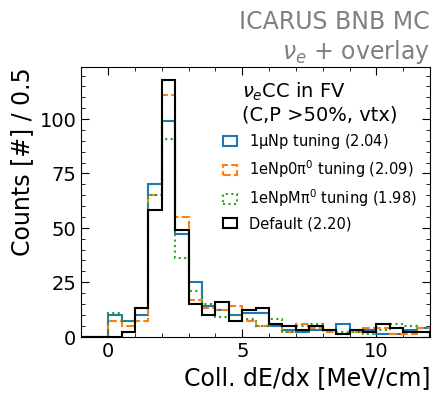

In [46]:
fig, ax = plt.subplots(figsize=(4.5, 3.5))

# Variable

# Var = "ind1dedx"
# width = 0.5; binning = numpy.arange(-1, 12+width, width)
# VarName = "Ind. 1 dE/dx [MeV/cm]"

# Var = "ind2dedx"
# width = 0.5; binning = numpy.arange(-1, 12+width, width)
# VarName = "Ind. 2 dE/dx [MeV/cm]"

Var = "colldedx"
width = 0.5; binning = numpy.arange(-1, 12+width, width)
VarName = "Coll. dE/dx [MeV/cm]"

## 2D + DNN-ROI, with pulse trains
Mask = (Reco_1uNp.isFV == 1) & (Reco_1uNp.hitcomp > 0.5) & (Reco_1uNp.hitpur > 0.5) & (Reco_1uNp.vtx_vstruth < 10)
ax.hist(Reco_1uNp[Mask][Var], bins=binning, histtype='step', lw=1.5, ec=f'C0', label=f'$\\mathrm{{1\\mu N p}}$ tuning ({numpy.median(Reco_1uNp[Mask][Var]):.2f})', density=False)

### 2D + DNN-ROI, without pulse trains
Mask = (Reco_1eNp0pi0.isFV == 1) & (Reco_1eNp0pi0.hitcomp > 0.5) & (Reco_1eNp0pi0.hitpur > 0.5) & (Reco_1eNp0pi0.vtx_vstruth < 10)
ax.hist(Reco_1eNp0pi0[Mask][Var], bins=binning, histtype='step', lw=1.5,ls='--', ec=f'C1', label=f'$\\mathrm{{1e N p 0 \\pi^0}}$ tuning ({numpy.median(Reco_1eNp0pi0[Mask][Var]):.2f})', density=False)

### 2D + legacy ROIs, with pulse trains
Mask = (Reco_1eNpMpi0.isFV == 1) & (Reco_1eNpMpi0.hitcomp > 0.5) & (Reco_1eNpMpi0.hitpur > 0.5) & (Reco_1eNpMpi0.vtx_vstruth < 10)
ax.hist(Reco_1eNpMpi0[Mask][Var], bins=binning, histtype='step', lw=1.5,ls=':', ec=f'C2', label=f'$\\mathrm{{1e N p M \\pi^0}}$ tuning ({numpy.median(Reco_1eNpMpi0[Mask][Var]):.2f})', density=False)

### 1D
Mask = (Reco_baseline.isFV == 1) & (Reco_baseline.hitcomp > 0.5) & (Reco_baseline.hitpur > 0.5) & (Reco_baseline.vtx_vstruth < 10)
ax.hist(Reco_baseline[Mask][Var], bins=binning, histtype='step', lw=1.5,ls='-', ec=f'black', label=f'Default ({numpy.median(Reco_baseline[Mask][Var]):.2f})', density=False)

# labels
ax.set_title("ICARUS BNB MC\n$\\nu_e$ + overlay", fontsize=17, loc='right', color='gray')
ax.set_xlabel(VarName, fontsize=17, loc='right')
ax.set_ylabel(f"Counts [#] / {width}", fontsize=17, loc='top')
leg = ax.legend(frameon=False, fancybox=False, fontsize=10.5, loc='upper right', handlelength=1, ncol=1, title='$\\nu_e$CC in FV\n(C,P >50%, vtx)')
leg.get_title().set_fontsize('14')

# ticks
ax.tick_params(labelsize=14, length=6, direction='in', right=True, top=True)
ax.tick_params(which='minor', length=3, direction='in', right=True, top=True)
ax.minorticks_on()
# ax.set_yscale('log')

# gfx
ax.set_xlim(binning[0], binning[-1])

fig.savefig(f"/exp/icarus/app/users/msotgia/analysis/twoDRecoStudies/showerValidations/V10Validation/202605/plots/NueCC_ShowerReco_{Var}.png", bbox_inches='tight', dpi=300)
plt.show()

/tmp/ipykernel_1376/3106044136.py:26: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  leg = ax.legend(frameon=False, fontsize=11, loc='upper right', handlelength=1, ncol=1, title='')


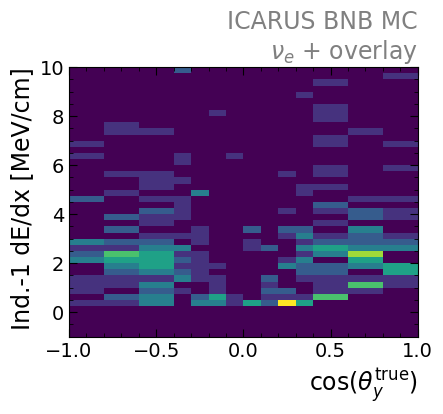

In [47]:
fig, ax = plt.subplots(figsize=(4.5, 3.5))

Reco = Reco_1uNp

Var = "ind1dedx"
width = 0.25; binning = numpy.arange(-1, 10+width, width)
VarName = "Ind.-1 dE/dx [MeV/cm]"

XVar = "dirytruth"
Xbinning = [-1, -0.8, -0.6, -0.4, -0.3, -0.2, -0.1, 0, 0.1, 0.2, 0.3, 0.4, 0.6, 0.8, 1]
XVarName = "cos($\\theta_y^{\\mathrm{true}}$)"

### 2D + DNN-ROI, with pulse trains
Mask = (Reco.isFV == 1) & (Reco.hitcomp > 0.5) & (Reco.hitpur > 0.5) & (Reco.vtx_vstruth < 10)
# ax.hist(numpy.clip(Reco[Mask][Var], binning[0], binning[-1]), bins=binning, histtype='step', lw=1.5, ec=f'C0', label=f'2D+DNN-ROI\nw/ trains ({numpy.median(Reco[Mask][Var]):.2f})', density=True)
ax.hist2d(
    Reco[Mask][XVar], Reco[Mask][Var], 
    bins = (Xbinning, binning),
    cmin = 0
)

# labels
ax.set_title("ICARUS BNB MC\n$\\nu_e$ + overlay", fontsize=17, loc='right', color='gray')
ax.set_xlabel(XVarName, fontsize=17, loc='right')
ax.set_ylabel(VarName, fontsize=17, loc='top')
leg = ax.legend(frameon=False, fontsize=11, loc='upper right', handlelength=1, ncol=1, title='')
 #leg.get_title().set_fontsize('15')

# ticks
ax.tick_params(labelsize=14, length=6, direction='in', right=True, top=True)
ax.tick_params(which='minor', length=3, direction='in', right=True, top=True)
ax.minorticks_on()
# ax.set_yscale('log')

# gfx
ax.set_xlim(Xbinning[0], Xbinning[-1])
ax.set_ylim(binning[0], binning[-1])
fig.savefig(f"/exp/icarus/app/users/msotgia/analysis/twoDRecoStudies/showerValidations/V10Validation/202605/plots/V10Validation_ShowerReco_NueCC_2D_{XVar}_{Var}.png", bbox_inches='tight', dpi=300)
plt.show()

/tmp/ipykernel_1376/1873659410.py:26: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  leg = ax.legend(frameon=False, fontsize=11, loc='upper right', handlelength=1, ncol=1, title='')


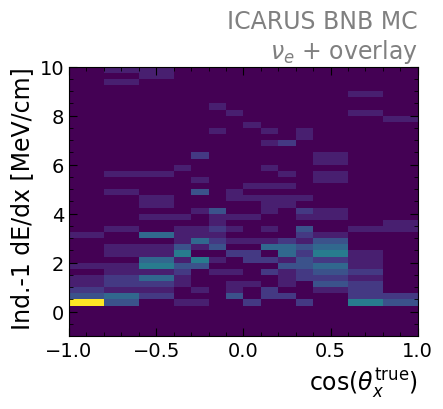

In [48]:
fig, ax = plt.subplots(figsize=(4.5, 3.5))

Reco = Reco_1uNp

Var = "ind1dedx"
width = 0.25; binning = numpy.arange(-1, 10+width, width)
VarName = "Ind.-1 dE/dx [MeV/cm]"

XVar = "dirxtruth"
Xbinning = [-1, -0.8, -0.6, -0.4, -0.3, -0.2, -0.1, 0, 0.1, 0.2, 0.3, 0.4, 0.6, 0.8, 1]
XVarName = "cos($\\theta_x^{\\mathrm{true}}$)"

### 2D + DNN-ROI, with pulse trains
Mask = (Reco.isFV == 1) & (Reco.hitcomp > 0.5) & (Reco.hitpur > 0.5) & (Reco.vtx_vstruth < 10)
# ax.hist(numpy.clip(Reco[Mask][Var], binning[0], binning[-1]), bins=binning, histtype='step', lw=1.5, ec=f'C0', label=f'2D+DNN-ROI\nw/ trains ({numpy.median(Reco[Mask][Var]):.2f})', density=True)
ax.hist2d(
    Reco[Mask][XVar], Reco[Mask][Var], 
    bins = (Xbinning, binning),
    cmin = 0
)

# labels
ax.set_title("ICARUS BNB MC\n$\\nu_e$ + overlay", fontsize=17, loc='right', color='gray')
ax.set_xlabel(XVarName, fontsize=17, loc='right')
ax.set_ylabel(VarName, fontsize=17, loc='top')
leg = ax.legend(frameon=False, fontsize=11, loc='upper right', handlelength=1, ncol=1, title='')
 #leg.get_title().set_fontsize('15')

# ticks
ax.tick_params(labelsize=14, length=6, direction='in', right=True, top=True)
ax.tick_params(which='minor', length=3, direction='in', right=True, top=True)
ax.minorticks_on()
# ax.set_yscale('log')

# gfx
ax.set_xlim(Xbinning[0], Xbinning[-1])
ax.set_ylim(binning[0], binning[-1])
fig.savefig(f"/exp/icarus/app/users/msotgia/analysis/twoDRecoStudies/showerValidations/V10Validation/202605/plots/V10Validation_ShowerReco_NueCC_2D_{XVar}_{Var}.png", bbox_inches='tight', dpi=300)
plt.show()

/tmp/ipykernel_1376/3666302152.py:27: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  leg = ax.legend(frameon=False, fontsize=11, loc='upper right', handlelength=1, ncol=1, title='')


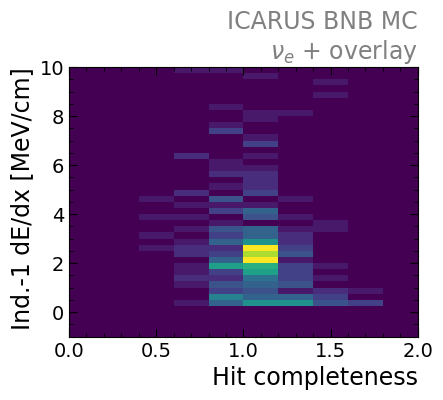

In [49]:
fig, ax = plt.subplots(figsize=(4.5, 3.5))

Reco = Reco_1uNp

Var = "ind1dedx"
width = 0.25; binning = numpy.arange(-1, 10+width, width)
VarName = "Ind.-1 dE/dx [MeV/cm]"

XVar = "hitcomp"
width = 0.2; Xbinning = numpy.arange(0, 2+width, width)
# Xbinning = [-1, -0.8, -0.6, -0.4, -0.3, -0.2, -0.1, 0, 0.1, 0.2, 0.3, 0.4, 0.6, 0.8, 1]
XVarName = "Hit completeness"

### 2D + DNN-ROI, with pulse trains
Mask = (Reco.isFV == 1) & (Reco.hitcomp > 0.5) & (Reco.hitpur > 0.5) & (Reco.vtx_vstruth < 10)
# ax.hist(numpy.clip(Reco[Mask][Var], binning[0], binning[-1]), bins=binning, histtype='step', lw=1.5, ec=f'C0', label=f'2D+DNN-ROI\nw/ trains ({numpy.median(Reco[Mask][Var]):.2f})', density=True)
ax.hist2d(
    Reco[Mask][XVar], Reco[Mask][Var], 
    bins = (Xbinning, binning),
    cmin = 0
)

# labels
ax.set_title("ICARUS BNB MC\n$\\nu_e$ + overlay", fontsize=17, loc='right', color='gray')
ax.set_xlabel(XVarName, fontsize=17, loc='right')
ax.set_ylabel(VarName, fontsize=17, loc='top')
leg = ax.legend(frameon=False, fontsize=11, loc='upper right', handlelength=1, ncol=1, title='')
 #leg.get_title().set_fontsize('15')

# ticks
ax.tick_params(labelsize=14, length=6, direction='in', right=True, top=True)
ax.tick_params(which='minor', length=3, direction='in', right=True, top=True)
ax.minorticks_on()
# ax.set_yscale('log')

# gfx
ax.set_xlim(Xbinning[0], Xbinning[-1])
ax.set_ylim(binning[0], binning[-1])
fig.savefig(f"/exp/icarus/app/users/msotgia/analysis/twoDRecoStudies/showerValidations/V10Validation/202605/plots/V10Validation_ShowerReco_NueCC_2D_{XVar}_{Var}.png", bbox_inches='tight', dpi=300)
plt.show()

/tmp/ipykernel_1376/3379511114.py:27: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  leg = ax.legend(frameon=False, fontsize=11, loc='upper right', handlelength=1, ncol=1, title='')


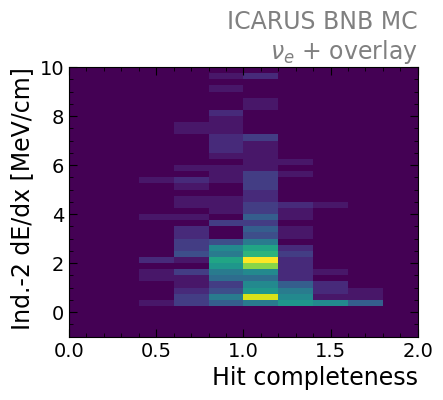

In [50]:
fig, ax = plt.subplots(figsize=(4.5, 3.5))

Reco = Reco_1uNp

Var = "ind2dedx"
width = 0.25; binning = numpy.arange(-1, 10+width, width)
VarName = "Ind.-2 dE/dx [MeV/cm]"

XVar = "hitcomp"
width = 0.2; Xbinning = numpy.arange(0, 2+width, width)
# Xbinning = [-1, -0.8, -0.6, -0.4, -0.3, -0.2, -0.1, 0, 0.1, 0.2, 0.3, 0.4, 0.6, 0.8, 1]
XVarName = "Hit completeness"

### 2D + DNN-ROI, with pulse trains
Mask = (Reco.isFV == 1) & (Reco.hitcomp > 0.5) & (Reco.hitpur > 0.5) & (Reco.vtx_vstruth < 10)
# ax.hist(numpy.clip(Reco[Mask][Var], binning[0], binning[-1]), bins=binning, histtype='step', lw=1.5, ec=f'C0', label=f'2D+DNN-ROI\nw/ trains ({numpy.median(Reco[Mask][Var]):.2f})', density=True)
ax.hist2d(
    Reco[Mask][XVar], Reco[Mask][Var], 
    bins = (Xbinning, binning),
    cmin = 0
)

# labels
ax.set_title("ICARUS BNB MC\n$\\nu_e$ + overlay", fontsize=17, loc='right', color='gray')
ax.set_xlabel(XVarName, fontsize=17, loc='right')
ax.set_ylabel(VarName, fontsize=17, loc='top')
leg = ax.legend(frameon=False, fontsize=11, loc='upper right', handlelength=1, ncol=1, title='')
 #leg.get_title().set_fontsize('15')

# ticks
ax.tick_params(labelsize=14, length=6, direction='in', right=True, top=True)
ax.tick_params(which='minor', length=3, direction='in', right=True, top=True)
ax.minorticks_on()
# ax.set_yscale('log')

# gfx
ax.set_xlim(Xbinning[0], Xbinning[-1])
ax.set_ylim(binning[0], binning[-1])
fig.savefig(f"/exp/icarus/app/users/msotgia/analysis/twoDRecoStudies/showerValidations/V10Validation/202605/plots/V10Validation_ShowerReco_NueCC_2D_{XVar}_{Var}.png", bbox_inches='tight', dpi=300)
plt.show()

/tmp/ipykernel_1376/801822625.py:26: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  leg = ax.legend(frameon=False, fontsize=11, loc='upper right', handlelength=1, ncol=1, title='')


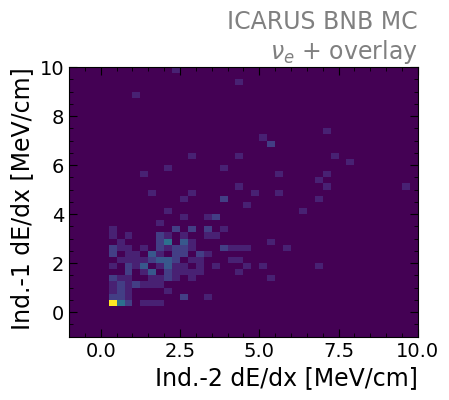

In [75]:
fig, ax = plt.subplots(figsize=(4.5, 3.5))

Reco = Reco_1uNp

Var = "ind1dedx"
width = 0.25; binning = numpy.arange(-1, 10+width, width)
VarName = "Ind.-1 dE/dx [MeV/cm]"

XVar = "ind2dedx"
width = 0.25; Xbinning = numpy.arange(-1, 10+width, width)
XVarName = "Ind.-2 dE/dx [MeV/cm]"

### 2D + DNN-ROI, with pulse trains
Mask = (Reco.isFV == 1) & (Reco.hitcomp > 0.5) & (Reco.hitpur > 0.5) & (Reco.vtx_vstruth < 10)
# ax.hist(numpy.clip(Reco[Mask][Var], binning[0], binning[-1]), bins=binning, histtype='step', lw=1.5, ec=f'C0', label=f'2D+DNN-ROI\nw/ trains ({numpy.median(Reco[Mask][Var]):.2f})', density=True)
ax.hist2d(
    Reco[Mask][XVar], Reco[Mask][Var], 
    bins = (Xbinning, binning),
    cmin = 0
)

# labels
ax.set_title("ICARUS BNB MC\n$\\nu_e$ + overlay", fontsize=17, loc='right', color='gray')
ax.set_xlabel(XVarName, fontsize=17, loc='right')
ax.set_ylabel(VarName, fontsize=17, loc='top')
leg = ax.legend(frameon=False, fontsize=11, loc='upper right', handlelength=1, ncol=1, title='')
 #leg.get_title().set_fontsize('15')

# ticks
ax.tick_params(labelsize=14, length=6, direction='in', right=True, top=True)
ax.tick_params(which='minor', length=3, direction='in', right=True, top=True)
ax.minorticks_on()
# ax.set_yscale('log')

# gfx
ax.set_xlim(Xbinning[0], Xbinning[-1])
ax.set_ylim(binning[0], binning[-1])
fig.savefig(f"/exp/icarus/app/users/msotgia/analysis/twoDRecoStudies/showerValidations/V10Validation/202605/plots/V10Validation_ShowerReco_NueCC_2D_{XVar}_{Var}.png", bbox_inches='tight', dpi=300)
plt.show()

/tmp/ipykernel_1376/1477517729.py:26: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  leg = ax.legend(frameon=False, fontsize=11, loc='upper right', handlelength=1, ncol=1, title='')


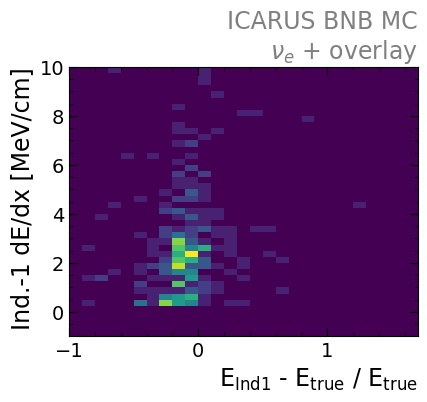

In [76]:
fig, ax = plt.subplots(figsize=(4.5, 3.5))

Reco = Reco_1uNp

Var = "ind1dedx"
width = 0.25; binning = numpy.arange(-1, 10+width, width)
VarName = "Ind.-1 dE/dx [MeV/cm]"

XVar = "ind1energy_vstruth"
width = 0.1; Xbinning = numpy.arange(-1, 1.7+width, width)
XVarName = "E$_{\mathrm{Ind1}}$ - E$_{\mathrm{true}}$ / E$_{\mathrm{true}}$"

### 2D + DNN-ROI, with pulse trains
Mask = (Reco.isFV == 1) & (Reco.hitcomp > 0.5) & (Reco.hitpur > 0.5) & (Reco.vtx_vstruth < 10)
# ax.hist(numpy.clip(Reco[Mask][Var], binning[0], binning[-1]), bins=binning, histtype='step', lw=1.5, ec=f'C0', label=f'2D+DNN-ROI\nw/ trains ({numpy.median(Reco[Mask][Var]):.2f})', density=True)
ax.hist2d(
    Reco[Mask][XVar], Reco[Mask][Var], 
    bins = (Xbinning, binning),
    cmin = 0
)

# labels
ax.set_title("ICARUS BNB MC\n$\\nu_e$ + overlay", fontsize=17, loc='right', color='gray')
ax.set_xlabel(XVarName, fontsize=17, loc='right')
ax.set_ylabel(VarName, fontsize=17, loc='top')
leg = ax.legend(frameon=False, fontsize=11, loc='upper right', handlelength=1, ncol=1, title='')
 #leg.get_title().set_fontsize('15')

# ticks
ax.tick_params(labelsize=14, length=6, direction='in', right=True, top=True)
ax.tick_params(which='minor', length=3, direction='in', right=True, top=True)
ax.minorticks_on()
# ax.set_yscale('log')

# gfx
ax.set_xlim(Xbinning[0], Xbinning[-1])
ax.set_ylim(binning[0], binning[-1])
fig.savefig(f"/exp/icarus/app/users/msotgia/analysis/twoDRecoStudies/showerValidations/V10Validation/202605/plots/V10Validation_ShowerReco_NueCC_2D_{XVar}_{Var}.png", bbox_inches='tight', dpi=300)
plt.show()

/tmp/ipykernel_1376/1088700911.py:26: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  leg = ax.legend(frameon=False, fontsize=11, loc='upper right', handlelength=1, ncol=1, title='')


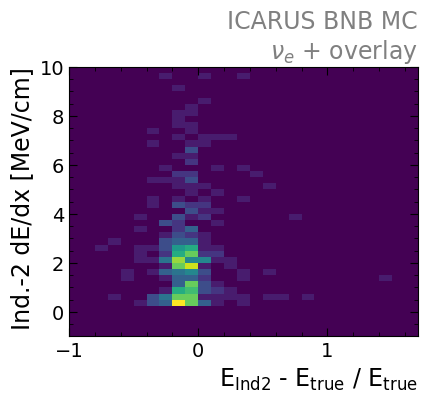

In [77]:
fig, ax = plt.subplots(figsize=(4.5, 3.5))

Reco = Reco_1uNp

Var = "ind2dedx"
width = 0.25; binning = numpy.arange(-1, 10+width, width)
VarName = "Ind.-2 dE/dx [MeV/cm]"

XVar = "ind2energy_vstruth"
width = 0.1; Xbinning = numpy.arange(-1, 1.7+width, width)
XVarName = "E$_{\mathrm{Ind2}}$ - E$_{\mathrm{true}}$ / E$_{\mathrm{true}}$"

### 2D + DNN-ROI, with pulse trains
Mask = (Reco.isFV == 1) & (Reco.hitcomp > 0.5) & (Reco.hitpur > 0.5) & (Reco.vtx_vstruth < 10)
# ax.hist(numpy.clip(Reco[Mask][Var], binning[0], binning[-1]), bins=binning, histtype='step', lw=1.5, ec=f'C0', label=f'2D+DNN-ROI\nw/ trains ({numpy.median(Reco[Mask][Var]):.2f})', density=True)
ax.hist2d(
    Reco[Mask][XVar], Reco[Mask][Var], 
    bins = (Xbinning, binning),
    cmin = 0
)

# labels
ax.set_title("ICARUS BNB MC\n$\\nu_e$ + overlay", fontsize=17, loc='right', color='gray')
ax.set_xlabel(XVarName, fontsize=17, loc='right')
ax.set_ylabel(VarName, fontsize=17, loc='top')
leg = ax.legend(frameon=False, fontsize=11, loc='upper right', handlelength=1, ncol=1, title='')
 #leg.get_title().set_fontsize('15')

# ticks
ax.tick_params(labelsize=14, length=6, direction='in', right=True, top=True)
ax.tick_params(which='minor', length=3, direction='in', right=True, top=True)
ax.minorticks_on()
# ax.set_yscale('log')

# gfx
ax.set_xlim(Xbinning[0], Xbinning[-1])
ax.set_ylim(binning[0], binning[-1])
fig.savefig(f"/exp/icarus/app/users/msotgia/analysis/twoDRecoStudies/showerValidations/V10Validation/202605/plots/V10Validation_ShowerReco_NueCC_2D_{XVar}_{Var}.png", bbox_inches='tight', dpi=300)
plt.show()

### Energy resolution

In [72]:
def CrystalBall(
    x, 
    alpha, 
    n, 
    mu, 
    sigma, 
    N
):
    
    t = (x - mu) / sigma
    A = (n / abs(alpha)) ** n * numpy.exp(-alpha**2 / 2)
    B = n / abs(alpha) - abs(alpha)
    C = (n / abs(alpha)) * (1 / (n - 1)) * numpy.exp(-alpha**2 / 2)
    
    gaussian = N * numpy.exp(-t**2 / 2)
    power_law = N * A * (B - t)**-n
    
    return numpy.where(t > -alpha, gaussian, power_law)

In [73]:
def CaloRes(E, a, b, c):
    """
    Calculate the relative energy resolution of a calorimeter.

    Parameters:
        E (float or ndarray): Energy of the incident particle.
        a (float): Stochastic term.
        b (float): Noise term.
        c (float): Constant term.

    Returns:
        float or ndarray: Relative energy resolution (sigma_E / E).
    """
    stochastic = a / numpy.sqrt(E)
    noise = b / E
    constant = c
    return numpy.sqrt(stochastic**2 + noise**2 + constant**2)

In [84]:
def ExtractEnergyResolution(
    Reco,
    Binning,
    Is1D = False,
    DebugPlots = True
):
    # Do this on the three planes
    TrueEnergies = ['ind1energytruth', 'ind2energytruth', 'collenergytruth']
    Resolutions = ['ind1energy_vstruth', 'ind2energy_vstruth', 'collenergy_vstruth']
    FitResults = []
    
    for PLANE in range(3):

        TrueEnergy = TrueEnergies[PLANE]
        EnergyRes = Resolutions[PLANE]
        FitResults_ThisPlane = []
        
        # Bin the true energy at each plane
        Reco[TrueEnergy + '_binned'] = pandas.cut(
            Reco[TrueEnergy], 
            bins = Binning, 
            right = False
        )

        if DebugPlots:
            print("Plane " + str(PLANE))
            fig, ax = plt.subplots(figsize=(5, 4))
            ax.set_title(f"Plane {PLANE}")
            
        # Loop over each true energy bin
        for i, EnergyBinDf in Reco.groupby(TrueEnergy + '_binned', observed = False):

            # Energy resolution in this true energy bin
            BIN_WIDTH = 0.075; binning = numpy.arange(-1, 0.6+BIN_WIDTH, BIN_WIDTH)
            y, b = numpy.histogram(
                EnergyBinDf[EnergyRes], 
                bins = binning, 
            )
            x = (b[:-1] + b[1:]) / 2.
            if DebugPlots:
                y, b, _ = ax.hist(
                    EnergyBinDf[EnergyRes], 
                    bins = binning, 
                    histtype = 'step', 
                    lw = 2, 
                    # ec = colors[binNumber], 
                    density = False, 
                    label=  str(i) + " GeV")
            
            # Fit this energy resolution with an educated guess
            Peak = numpy.max(y)
            PeakPosition = (b[numpy.argmax(y)] + b[numpy.argmax(y)+1]) / 2
            StdGuess = numpy.sqrt(numpy.average((x - PeakPosition)**2, weights=y))
            p0 = [
                1.5, 
                1., 
                PeakPosition, 
                StdGuess, 
                Peak
            ]
            bounds = (
                [0, 0, -numpy.inf, 0, 0],               ###< lower bounds
                [numpy.inf, numpy.inf, numpy.inf, numpy.inf, numpy.inf] ###< upper bounds
            )  
            MIN_FIT = PeakPosition - 0.7
            MAX_FIT = PeakPosition + 0.4
            mask = (x > MIN_FIT) & (x < MAX_FIT)

            # 1D is essentially random. Needs care.
            if Is1D == True:
                if PLANE == 0:
                    mask = mask & ~((x > -0.7) & (x < -0.5))
                elif PLANE == 2:
                    mask = mask & ~((x > -0.6) & (x < -0.2))
                
            popt, pcov = curve_fit(
                CrystalBall, 
                x[mask], 
                y[mask], 
                p0 = p0,
                bounds = bounds,
                maxfev = 3000
            )
            errors = numpy.sqrt(numpy.diag(pcov))

            if DebugPlots:
                print(f"Guess = 1.5, 1, {PeakPosition}, {StdGuess}, {Peak}")
                print("Fit = ", popt)
                alpha_fit, n_fit, mu_fit, sigma_fit, N_fit = popt
                domain = numpy.arange(binning[0], binning[-1], 0.01)
                ax.plot(
                    domain, 
                    CrystalBall(domain, *popt), 
                    ls = '--', 
                    lw = 2, 
                    c = 'black'
                )
                ax.axvspan(MIN_FIT, MAX_FIT, zorder=-3, alpha=0.05, fc='green')

            FitResults_ThisPlane.append([popt[3], errors[3]])

        FitResults.append(FitResults_ThisPlane)
        
        if DebugPlots:
            ax.legend()

    return FitResults

In [89]:
width = 0.5; bins = numpy.arange(0., 1.5+width, width)


'''
Results_DNN_PT = ExtractEnergyResolution(
    Reco_DNN_PT,
    bins,
    False,
    True
)
'''

'''
Results_DNN_NPT = ExtractEnergyResolution(
    Reco_DNN_NPT,
    bins,
    False,
    True
)
'''

'''
Results_noDNN = ExtractEnergyResolution(
    Reco_noDNN,
    bins,
    False,
    True
)
'''

'''
Results_1D = ExtractEnergyResolution(
    Reco_1D,
    bins,
    True,
    True
)
'''

'\nResults_1D = ExtractEnergyResolution(\n    Reco_1D,\n    bins,\n    True,\n    True\n)\n'

0
1
2


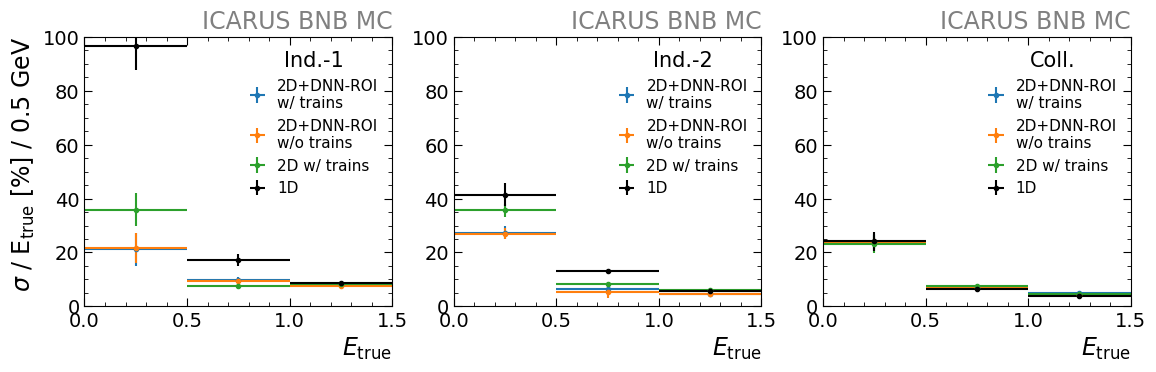

In [95]:
fig, ax = plt.subplots(figsize=(4.5 * 3, 3.5), ncols=3)

# Choose plane
PLANE = 0
Planes = ["Ind.-1", "Ind.-2", "Coll."]
Names = ["E$_{\mathrm{Ind1}}$ - E$_{\mathrm{true}}$ / E$_{\mathrm{true}}$",
         "E$_{\mathrm{Ind2}}$ - E$_{\mathrm{true}}$ / E$_{\mathrm{true}}$",
         "E$_{\mathrm{Coll}}$ - E$_{\mathrm{true}}$ / E$_{\mathrm{true}}$"]

for i in range(3):

    PLANE = i

    print(PLANE)
    
    # Binning
    width = 0.5; bins = numpy.arange(0., 1.5+width, width)
    x = (bins[:-1] + bins[1:]) / 2.
    xerr = (x[1] - x[0]) / 2.
    
    ### 2D + DNN-ROI, with pulse trains
    PlaneResults = numpy.array(Results_DNN_PT[PLANE]).T
    FracResolution = 100. * numpy.abs(PlaneResults[0]) / x
    FracResolution_Err = 100. * numpy.abs(PlaneResults[1]) / x
    ax[i].errorbar(x, FracResolution, xerr=xerr, yerr=FracResolution_Err, ls='', c='C0', marker='.', elinewidth=1.5, label=f'2D+DNN-ROI\nw/ trains')

    ### 2D + DNN-ROI, without pulse trains
    PlaneResults = numpy.array(Results_DNN_NPT[PLANE]).T
    FracResolution = 100. * numpy.abs(PlaneResults[0]) / x
    FracResolution_Err = 100. * numpy.abs(PlaneResults[1]) / x
    ax[i].errorbar(x, FracResolution, xerr=xerr, yerr=FracResolution_Err, ls='', c='C1', marker='.', elinewidth=1.5, label=f'2D+DNN-ROI\nw/o trains')

    ### 2D + legacy ROI, with pulse trains
    PlaneResults = numpy.array(Results_noDNN[PLANE]).T
    FracResolution = 100. * numpy.abs(PlaneResults[0]) / x
    FracResolution_Err = 100. * numpy.abs(PlaneResults[1]) / x
    ax[i].errorbar(x, FracResolution, xerr=xerr, yerr=FracResolution_Err, ls='', c='C2', marker='.', elinewidth=1.5, label=f'2D w/ trains')

    ### 1D
    PlaneResults = numpy.array(Results_1D[PLANE]).T
    FracResolution = 100. * numpy.abs(PlaneResults[0]) / x
    FracResolution_Err = 100. * numpy.abs(PlaneResults[1]) / x
    ax[i].errorbar(x, FracResolution, xerr=xerr, yerr=FracResolution_Err, ls='', c='black', marker='.', elinewidth=1.5, label=f'1D')
    
    # labels
    ax[i].set_title("ICARUS BNB MC", fontsize=17, loc='right', color='gray')
    ax[i].set_xlabel("$E_{\\mathrm{true}}$", fontsize=17, loc='right')
    leg = ax[i].legend(frameon=False, fontsize=11, loc='upper right', handlelength=1, ncol=1, title=f'{Planes[PLANE]}')
    leg.get_title().set_fontsize('15')
    
    # ticks
    ax[i].tick_params(labelsize=14, length=6, direction='in', right=True, top=True)
    ax[i].tick_params(which='minor', length=3, direction='in', right=True, top=True)
    ax[i].minorticks_on()
    # ax.set_yscale('log')
    
    # gfx
    ax[i].set_xlim(bins[0], bins[-1])
    ax[i].set_ylim(0, 100)

ax[0].set_ylabel("$\sigma$ / E$_{\mathrm{true}}$ [%]" + f" / {width} GeV", fontsize=17, loc='top')

fig.savefig(f"../202512/plots/NueCC_ShowerEnergyResolution_PerPlane.png", bbox_inches='tight', dpi=300)
plt.show()

In [70]:
Mask = (Reco.isFV == 1) & (Reco.hitcomp > 0.5) & (Reco.hitpur > 0.5) & (Reco.vtx_vstruth < 10) & (Reco.ind1dedx <1.5) & (Reco.dirxtruth < -0.5) & (Reco.ind2dedx < 1.5) & (Reco.ind1dedx > 0) & (Reco.ind2dedx > 0)
for line in Reco[Mask][['source', 'run', 'event', 'ind1dedx', 'ind2dedx', 'dirxtruth']].itertuples():
    print(line) 

Pandas(Index=55, source='msotgia_v10_06_00_06p03_overlay_run9435_B_bnb_nue_withOverlayFixed_1uNp_energyOnly_noPulses_v10_06_00_06p03_stage1_84146801_0.root', run=9435, event=29413, ind1dedx=0.341471, ind2dedx=0.325562, dirxtruth=-0.968434)
Pandas(Index=300, source='msotgia_v10_06_00_06p03_overlay_run9435_B_bnb_nue_withOverlayFixed_1uNp_energyOnly_noPulses_v10_06_00_06p03_stage1_84146803_0.root', run=9435, event=35855, ind1dedx=1.48419, ind2dedx=0.429737, dirxtruth=-0.713771)
Pandas(Index=549, source='msotgia_v10_06_00_06p03_overlay_run9435_B_bnb_nue_withOverlayFixed_1uNp_energyOnly_noPulses_v10_06_00_06p03_stage1_84146805_0.root', run=9435, event=43313, ind1dedx=1.34271, ind2dedx=0.405874, dirxtruth=-0.693557)
Pandas(Index=878, source='msotgia_v10_06_00_06p03_overlay_run9435_B_bnb_nue_withOverlayFixed_1uNp_energyOnly_noPulses_v10_06_00_06p03_stage1_84146807_0.root', run=9435, event=34896, ind1dedx=0.835989, ind2dedx=0.665818, dirxtruth=-0.648581)
Pandas(Index=1005, source='msotgia_v10_